### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

media consumo birra:  106.16062176165804
media consumo vino:  49.45077720207254
media consumo    :  80.99481865284974


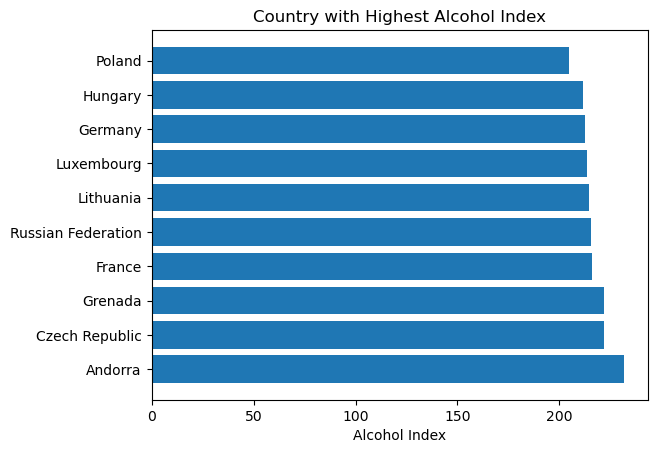

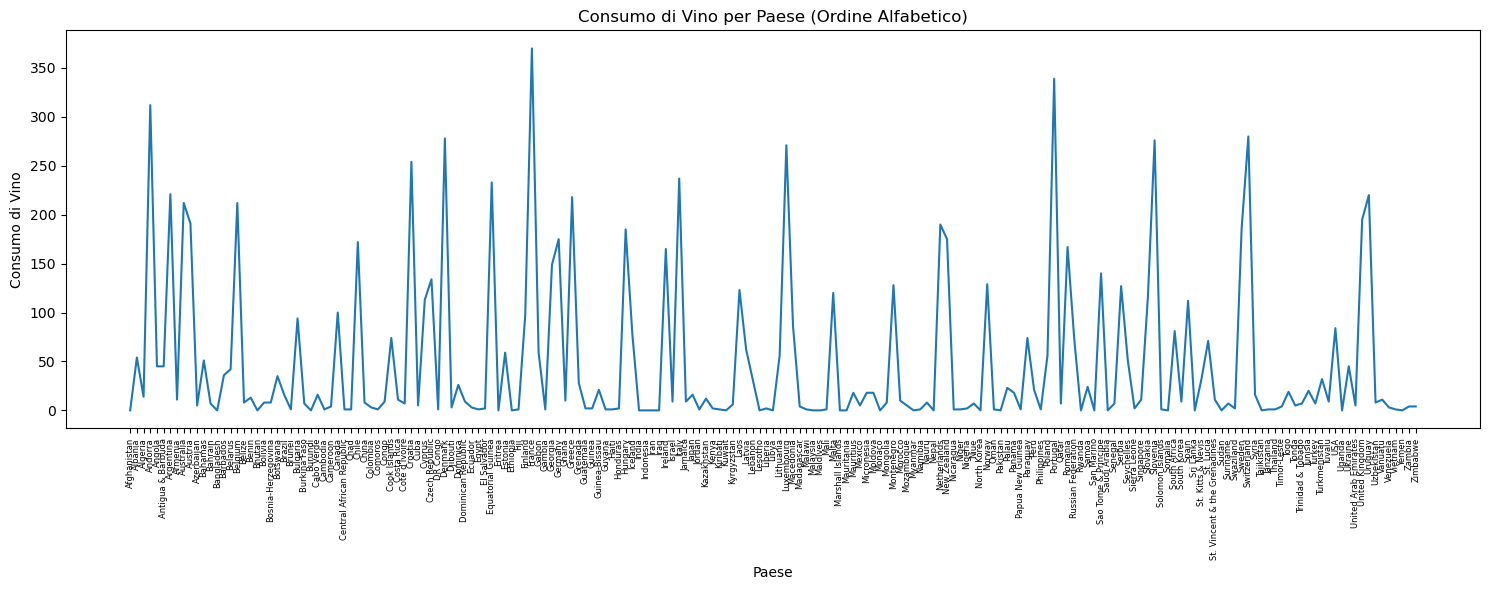

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")

df.sort_values(by="total_litres_of_pure_alcohol",ascending=False).head(10)
print("media consumo birra: ", df["beer_servings"].mean())
print("media consumo vino: ", df["wine_servings"].mean())
print("media consumo    : ", df["spirit_servings"].mean())
df["alcohol_index"] = (df["beer_servings"]+df["spirit_servings"]+df["wine_servings"])/3
plot_alcohol = df.sort_values("alcohol_index", ascending=False).head(10)

df[df["beer_servings"]>100]

plt.barh(plot_alcohol["country"]  , plot_alcohol["alcohol_index"], )
plt.xlabel("Alcohol Index")
plt.title("Country with Highest Alcohol Index")
plt.show()

df_sorted_country = df.sort_values(by="country")
plt.figure(figsize=(15, 6))
plt.plot(df_sorted_country["country"], df_sorted_country["wine_servings"], marker=None, linestyle='-')
plt.xlabel("Paese")
plt.ylabel("Consumo di Vino")
plt.title("Consumo di Vino per Paese (Ordine Alfabetico)")
plt.xticks(rotation=90, fontsize=6) # Molti paesi, serve un font piccolo
plt.tight_layout()
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [8]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df.head()
stipendio_medio = df.mean("salary_year_avg", skipna=True)


C:\Users\nicol\AppData\Local\Temp\ipykernel_26004\1237897074.py:9: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  stipendio_medio = df.mean("salary_year_avg", skipna=True)


ValueError: No axis named salary_year_avg for object type DataFrame

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [9]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
